# 미니프로젝트: 결측치·이상치·클래스 불균형 처리 (Vibe Coding)

#### <목표>
오늘 배운 **결측치/이상치 처리, Under/Oversampling, SVDD**를 **통신사 고객 이탈(Customer Churn) 데이터셋**에 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>
- Telco Customer Churn (통신사 고객 이탈 데이터)
- 고객의 인적사항, 가입 서비스, 요금·계약 정보와 이탈(Churn) 여부를 담은 데이터

| 변수명 | 설명 |
|:---:|:---|
| gender, SeniorCitizen, Partner, Dependents | 고객 인적사항 |
| tenure | 가입 개월 수 |
| PhoneService, MultipleLines, InternetService 등 | 가입 서비스 종류 |
| Contract, PaperlessBilling, PaymentMethod | 계약/결제 정보 |
| MonthlyCharges, TotalCharges | 월/누적 요금 |
| Churn | 이탈 여부 (Yes: 이탈, No: 유지) |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 분류 | `Churn` | 고객 정보로 이탈 여부 예측 |

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day4_miniproject.csv` 파일을 사용하기
- 타겟 변수: `Churn` (No: 유지, Yes: 이탈)

**[과제]** 써니는 통신사 고객 이탈 데이터를 분석하게 되었습니다. 분석에 필요한 라이브러리를 호출하고 데이터를 불러와 구조를 확인하는 코드를 AI와 상의해서 작성하세요.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import OneClassSVM

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
data = pd.read_csv("dataset/day4_miniproject.csv")
print("데이터 크기:", data.shape)
data.head()

데이터 크기: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1) 데이터 탐색 (EDA)

### 1-1) 기본 EDA 진행

**[과제]** 써니는 데이터 분석 전, 데이터의 구조적 및 통계적 정보가 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            6832 non-null   float64
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   6903 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     6832 non-null   object 


In [6]:
# 구조
print("크기:", data.shape)
print("결측치:\n", data.isnull().sum()[data.isnull().sum() > 0])
print("중복:", data.duplicated().sum())

data.info()        # 타입, non-null 개수
data.head()        # 상위 5행

# 통계
data.describe()    # 수치형 기술통계
data["Churn"].value_counts(normalize=True)  # 타겟 분포

크기: (7043, 20)
결측치:
 tenure             211
InternetService    140
PaymentMethod      211
MonthlyCharges     211
TotalCharges        11
dtype: int64
중복: 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            6832 non-null   float64
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   6903 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

**[과제]** 써니는 EDA를 통해 전처리가 필요한 부분을 발견했습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

> Tip: 'Churn' 변수의 타입이나 값 표기 방식

In [7]:
data_clean = data.copy()

# 1) 중복 제거
data_clean = data_clean.drop_duplicates()
print("중복 제거 후:", data_clean.shape)

# 2) 타겟 인코딩 (Yes=1, No=0)
data_clean["Churn"] = data_clean["Churn"].map({"No": 0, "Yes": 1})

# 3) 결측치 처리
# 수치형 → 중앙값, 범주형 → 최빈값
num_cols = data_clean.select_dtypes(include="number").columns
cat_cols = data_clean.select_dtypes(include="object").columns

for col in num_cols:
    data_clean[col] = data_clean[col].fillna(data_clean[col].median())
for col in cat_cols:
    data_clean[col] = data_clean[col].fillna(data_clean[col].mode()[0])

# 4) 확인
print("남은 결측치:", data_clean.isnull().sum().sum())
print("Churn 분포:\n", data_clean["Churn"].value_counts(normalize=True))
data_clean.head()

중복 제거 후: (7025, 20)
남은 결측치: 0
Churn 분포:
 Churn
0    0.735374
1    0.264626
Name: proportion, dtype: float64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


### 1-2) 결측치 현황 파악

**[과제]** 써니는 데이터에 결측치가 존재하는지, 존재한다면 어떤 형태로 얼마나 있는지 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

### 1-3) 클래스 불균형 확인

**[과제]** 써니는 Churn 비율이 얼마나 불균형한지 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


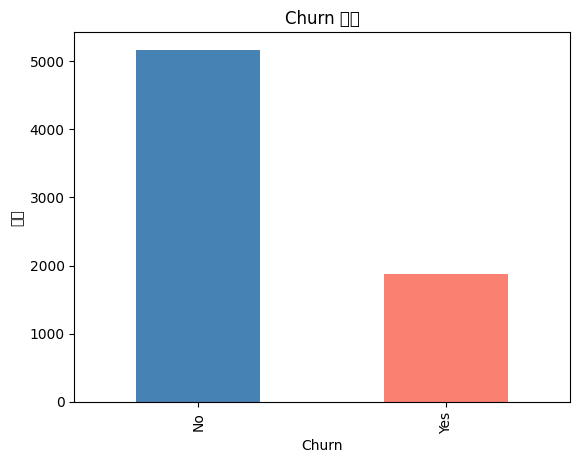

In [8]:
# 개수 & 비율
print(data["Churn"].value_counts())
print()
print(data["Churn"].value_counts(normalize=True).round(3) * 100)  # %

# 시각화
data["Churn"].value_counts().plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Churn 분포")
plt.xlabel("Churn"); plt.ylabel("개수")
plt.show()

### 1-4) 이상치 후보 탐색

**[과제]** 써니는 수치형 변수에 이상치가 있는지 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

SeniorCitizen: 이상치 1142개 (16.2%)
tenure: 이상치 0개 (0.0%)
MonthlyCharges: 이상치 0개 (0.0%)
TotalCharges: 이상치 0개 (0.0%)


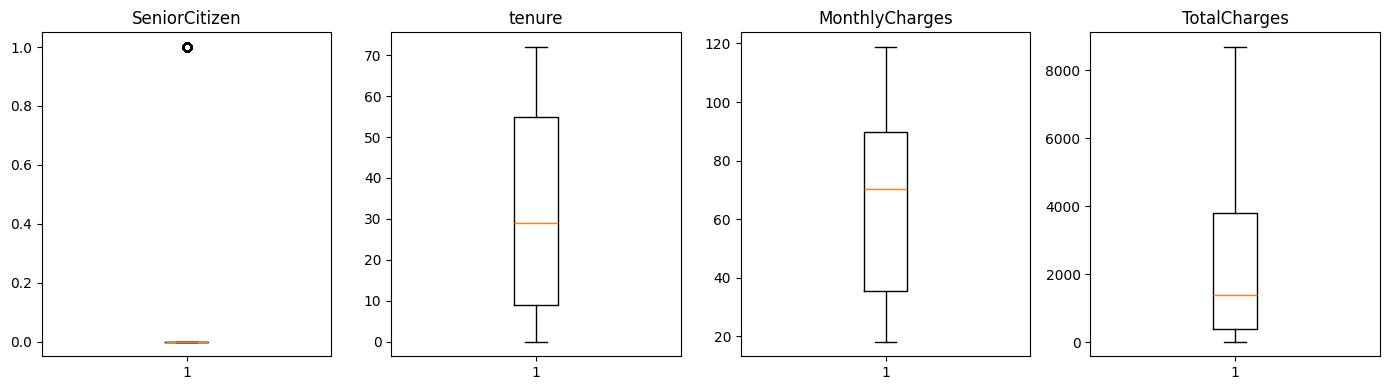

In [9]:
import matplotlib.pyplot as plt

num_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

# 1) IQR 기반 이상치 개수
for col in num_cols:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(f"{col}: 이상치 {len(outliers)}개 ({len(outliers)/len(data)*100:.1f}%)")

# 2) Box Plot 시각화
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, num_cols):
    ax.boxplot(data[col].dropna())
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 2) 결측치 처리

**[과제]** 써니는 데이터셋에 존재하는 결측치를 제거하거나 대치하려 합니다.

이때 변수마다 분포나 특성이 다르면 적합한 대치법도 달라질 수 있다고 생각합니다.

AI와 상의하여 변수별로 제거와 대치 중 어떤 방법이 적합한지 결정하고, 대치를 선택했다면 값 기반, 통계 기반(평균/중앙값/최빈값), 머신러닝 기반(KNN Imputer) 중 어떤 방식이 적합한지 정하여 적용해보세요.

In [10]:
from sklearn.impute import KNNImputer

data_imp = data_clean.copy()  # 전처리(중복제거, Churn 인코딩) 후 데이터

# ① TotalCharges — 값 기반 (신규 고객: tenure=0 → 월요금으로 대치)
mask = data_imp["TotalCharges"].isnull()
data_imp.loc[mask, "TotalCharges"] = data_imp.loc[mask, "MonthlyCharges"]

# ② 범주형 — 통계 기반 (최빈값)
for col in ["InternetService", "PaymentMethod"]:
    data_imp[col] = data_imp[col].fillna(data_imp[col].mode()[0])

# ③ 수치형 — KNN Imputer
imputer = KNNImputer(n_neighbors=5)
data_imp[["tenure", "MonthlyCharges"]] = imputer.fit_transform(
    data_imp[["tenure", "MonthlyCharges"]]
)

# 확인
print("남은 결측치:", data_imp.isnull().sum().sum())
data_imp.isnull().sum()

남은 결측치: 0


gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 3) 이상치 처리

**[과제]** 써니는 데이터셋에 존재하는 이상치를 제거하고자 합니다.

다만 이탈(Churn) 고객이 실제로는 "정상 범위를 벗어난" 요금 및 이용 패턴을 가진 고객일 수 있다는 점이 마음에 걸립니다. 이상치 제거가 소수 클래스(Churn)를 함께 지워버릴 위험은 없는지 AI와 상의하여 검토하고 안전한 처리 기준을 정해 적용해 보세요.

In [11]:
# data_imp: 결측치 처리 완료 데이터
data_out = data_imp.copy()

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# 처리 전 Churn 분포 확인
print("【처리 전】")
print(f"전체: {len(data_out)}, Churn(1): {data_out['Churn'].sum()}")
print(f"Churn 비율: {data_out['Churn'].mean():.3f}\n")

# Winsorization: 상·하위 1% clip (행 유지)
for col in num_cols:
    lower = data_out[col].quantile(0.01)
    upper = data_out[col].quantile(0.99)
    data_out[col] = data_out[col].clip(lower, upper)

# 처리 후 확인
print("【처리 후】")
print(f"전체: {len(data_out)}, Churn(1): {data_out['Churn'].sum()}")
print(f"Churn 비율: {data_out['Churn'].mean():.3f}")
print(f"행 수 변화: {len(data_imp)} → {len(data_out)}")  # 동일해야 함

【처리 전】
전체: 7025, Churn(1): 1859
Churn 비율: 0.265

【처리 후】
전체: 7025, Churn(1): 1859
Churn 비율: 0.265
행 수 변화: 7025 → 7025


## 4) 데이터 분할 및 스케일링/인코딩

**[과제]** 써니는 모델 구축 전 학습/테스트 데이터를 나누려고 합니다. 클래스 불균형이 심한 상황에서 어떤 분할 방법이 적합할지 AI와 상의해서 정하고 나눠 보세요.

In [12]:
X = data_out.drop("Churn", axis=1)
Y = data_out["Churn"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,      # 80% 학습, 20% 테스트
    random_state=42,
    stratify=Y          # Churn 비율 유지
)

print("학습:", Y_train.value_counts(normalize=True).round(3))
print("테스트:", Y_test.value_counts(normalize=True).round(3))

학습: Churn
0    0.735
1    0.265
Name: proportion, dtype: float64
테스트: Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


**[과제]** 써니는 분할한 학습/테스트 데이터에 적절한 스케일링 및 인코딩을 적용하고자 합니다. AI와 상의하여 수치형 변수와 범주형 변수 각각에 적합한 스케일링 및 인코딩 방식을 정하고 적용해보세요.

In [13]:
# 1) 범주형 / 수치형 분리
cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = X_train.select_dtypes(include="number").columns.tolist()

# 2) One-Hot Encoding
X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_enc = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# train/test 컬럼 맞추기 (없는 컬럼은 0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# 3) StandardScaler (수치형만)
scaler = StandardScaler()
X_train_scaled = X_train_enc.copy()
X_test_scaled = X_test_enc.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train_enc[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_enc[num_cols])

# 확인
print("학습:", X_train_scaled.shape)
print("테스트:", X_test_scaled.shape)
X_train_scaled.head()

학습: (5620, 30)
테스트: (1405, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2982,-0.43984,0.814463,-1.505271,-0.540235,True,True,True,True,False,False,...,True,False,True,False,True,False,True,True,False,False
3695,-0.43984,-0.013412,1.138001,0.351815,False,True,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
5806,-0.43984,-1.255226,-1.547631,-0.998085,False,False,True,True,False,False,...,True,False,True,False,False,False,True,False,True,False
155,-0.43984,-0.758500,0.529710,-0.504341,False,True,True,True,False,False,...,False,False,False,True,False,False,True,False,False,False
460,-0.43984,-1.089651,-1.545936,-0.969330,True,False,True,True,False,False,...,True,False,True,False,False,False,False,False,False,True


In [17]:
# object 컬럼이 남아있으면 인코딩 안 된 것
print(X_train_scaled.select_dtypes(include="object").columns)

# 더미 변수 예시
print([c for c in X_train_scaled.columns if "Contract" in c])

Index([], dtype='object')
['Contract_One year', 'Contract_Two year']


## 5) 클래스 불균형 시각화 및 Resampling 적용

**[과제]** 써니는 Churn 여부에 따라 고객들의 데이터가 얼마나 잘 구분되는지 궁금합니다. t-SNE로 학습 데이터를 2차원에 시각화하여 두 클래스가 얼마나 겹쳐 있는지 AI와 함께 코드를 작성하고 분석해보세요.

/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/skl

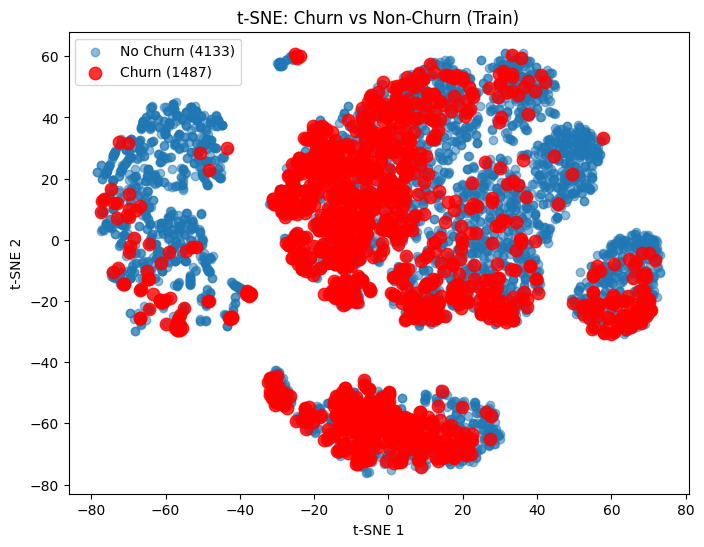

In [19]:
from sklearn.manifold import TSNE

# t-SNE: 고차원 → 2차원
X_embedded = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_train_scaled)

# 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X_embedded[Y_train == 0, 0], X_embedded[Y_train == 0, 1],
            label=f'No Churn ({(Y_train==0).sum()})', alpha=0.5)
plt.scatter(X_embedded[Y_train == 1, 0], X_embedded[Y_train == 1, 1],
            label=f'Churn ({(Y_train==1).sum()})', alpha=0.8, s=80, c='red')
plt.legend()
plt.title("t-SNE: Churn vs Non-Churn (Train)")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.show()

**[과제]** 써니는 클래스 불균형을 완화하기 위해 여러 Resampling 기법(TomekLinks, SMOTE, SMOTE+TomekLinks, ADASYN)을 학습 데이터에 적용해보고 t-SNE로 데이터 분포가 어떻게 변하는지 궁금해졌습니다. AI와 함께 관련 코드를 작성하고 분석해보세요.

> Tip: Resampling은 학습 데이터에만 적용하고, 테스트 데이터는 원본 그대로 유지할 것

In [20]:
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
from sklearn.manifold import TSNE

# 학습 데이터에만 적용 (테스트는 X_test_scaled, Y_test 그대로 유지)
X_TomekLinks, Y_TomekLinks = TomekLinks().fit_resample(X_train_scaled, Y_train)
X_SMOTE, Y_SMOTE = SMOTE(random_state=42).fit_resample(X_train_scaled, Y_train)
X_SMOTETomek, Y_SMOTETomek = SMOTETomek(random_state=42).fit_resample(X_train_scaled, Y_train)
X_ADASYN, Y_ADASYN = ADASYN(random_state=42).fit_resample(X_train_scaled, Y_train)

# 개수 확인
for name, Y_s in [("Before", Y_train), ("TomekLinks", Y_TomekLinks), 
                   ("SMOTE", Y_SMOTE), ("SMOTE+Tomek", Y_SMOTETomek), ("ADASYN", Y_ADASYN)]:
    print(f"{name}: {pd.Series(Y_s).value_counts().to_dict()}")

Before: {0: 4133, 1: 1487}
TomekLinks: {0: 3771, 1: 1487}
SMOTE: {0: 4133, 1: 4133}
SMOTE+Tomek: {0: 3985, 1: 3985}
ADASYN: {0: 4133, 1: 4087}


/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.


/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/skl

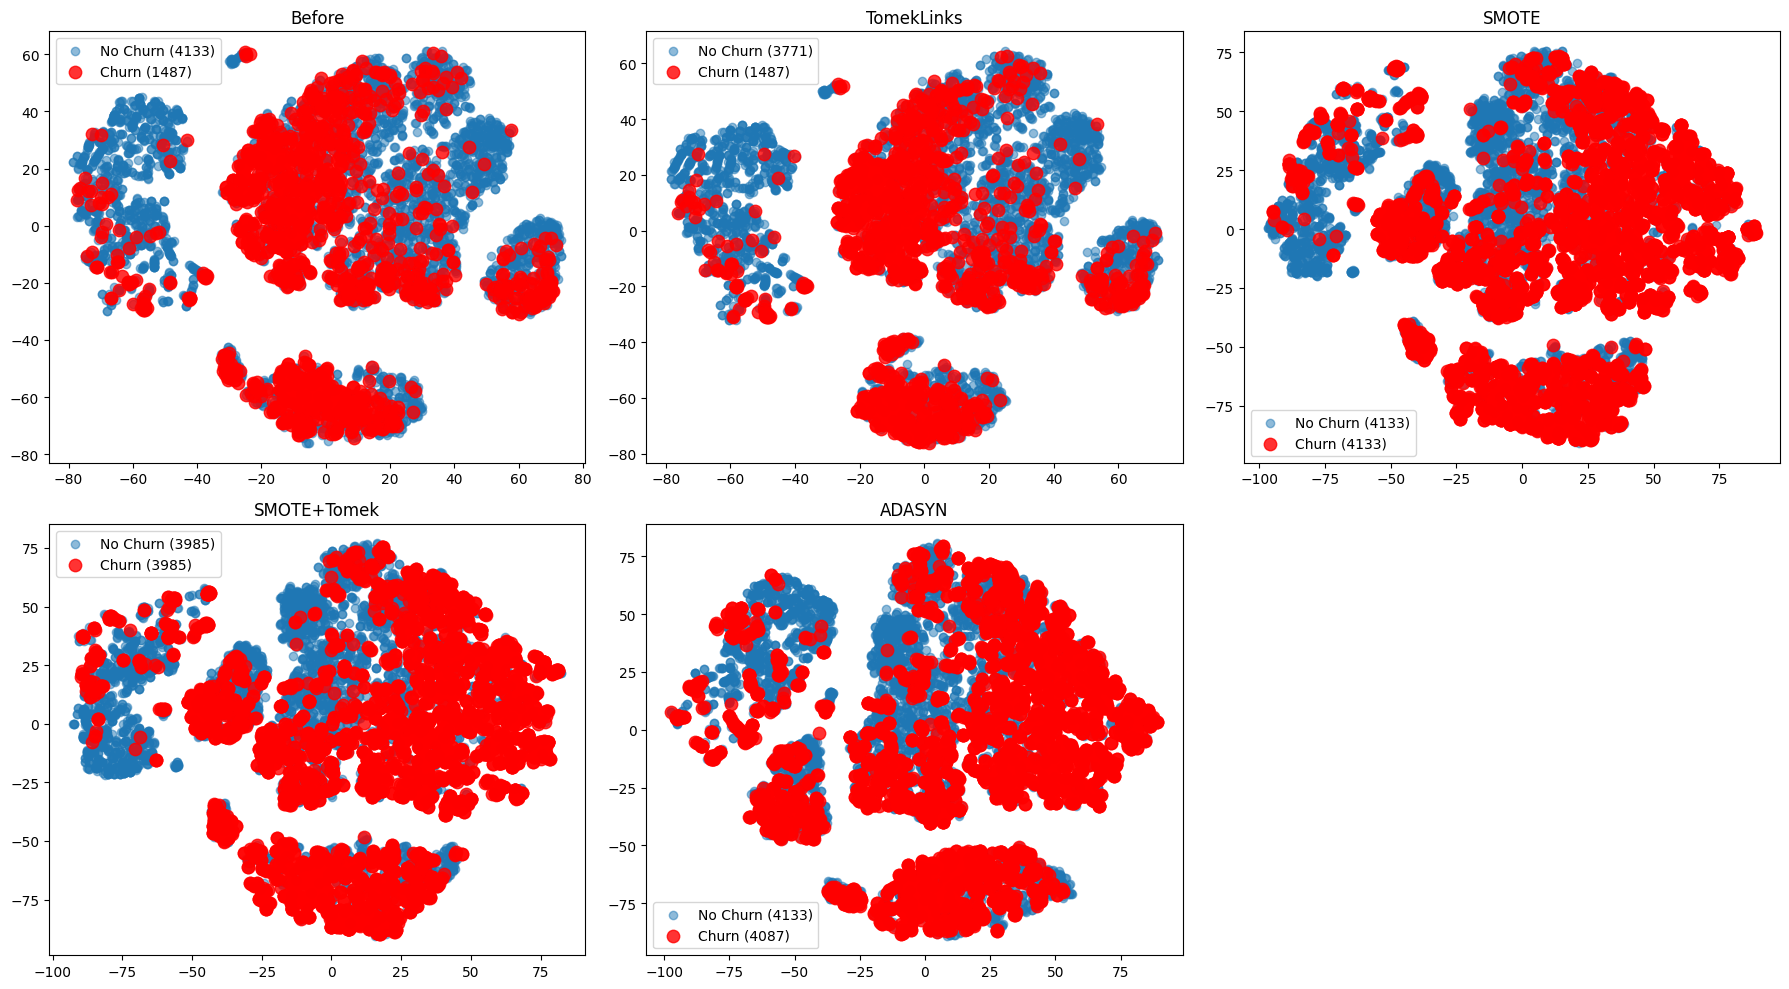

In [21]:
sampling_datasets = {
    "Before": (X_train_scaled, Y_train),
    "TomekLinks": (X_TomekLinks, Y_TomekLinks),
    "SMOTE": (X_SMOTE, Y_SMOTE),
    "SMOTE+Tomek": (X_SMOTETomek, Y_SMOTETomek),
    "ADASYN": (X_ADASYN, Y_ADASYN),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, (X_s, Y_s)) in enumerate(sampling_datasets.items()):
    emb = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_s)
    axes[i].scatter(emb[Y_s == 0, 0], emb[Y_s == 0, 1], label=f'No Churn ({(Y_s==0).sum()})', alpha=0.5)
    axes[i].scatter(emb[Y_s == 1, 0], emb[Y_s == 1, 1], label=f'Churn ({(Y_s==1).sum()})', alpha=0.8, s=80, c='red')
    axes[i].set_title(name)
    axes[i].legend()

axes[-1].axis("off")
plt.tight_layout()
plt.show()

**[과제]** 써니는 Resampling 기법별로 분류 모델(예: XGBoost)을 학습시켜 성능을 비교하려고 합니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

In [22]:
from xgboost import XGBClassifier

# Resampling 적용된 학습 데이터 (이전 셀에서 생성)
sampling_datasets = {
    "Before": (X_train_scaled, Y_train),
    "TomekLinks": (X_TomekLinks, Y_TomekLinks),
    "SMOTE": (X_SMOTE, Y_SMOTE),
    "SMOTE+Tomek": (X_SMOTETomek, Y_SMOTETomek),
    "ADASYN": (X_ADASYN, Y_ADASYN),
}

results = []
for name, (X_tr, Y_tr) in sampling_datasets.items():
    neg = (Y_tr == 0).sum()
    pos = (Y_tr == 1).sum()
    scale_pos_weight = neg / pos  # 불균형 비율 반영

    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss"
    )
    xgb.fit(X_tr, Y_tr)
    pred = xgb.predict(X_test_scaled)  # 테스트는 원본 유지

    results.append({
        "Method": name,
        "Accuracy": round(accuracy_score(Y_test, pred), 4),
        "Precision": round(precision_score(Y_test, pred, pos_label=1), 4),
        "Recall": round(recall_score(Y_test, pred, pos_label=1), 4),
        "F1-score": round(f1_score(Y_test, pred, pos_label=1), 4),
    })

pd.DataFrame(results)

,Method,Accuracy,Precision,Recall,F1-score
0,Before,0.7779,0.5676,0.6774,0.6176
1,TomekLinks,0.7737,0.5577,0.7016,0.6214
2,SMOTE,0.7616,0.5418,0.6452,0.5890
3,SMOTE+Tomek,0.7772,0.5701,0.6452,0.6053
4,ADASYN,0.7530,0.5281,0.6317,0.5753


## 6) SVDD (One-Class SVM) 적용

**[과제]** 써니는 Resampling 방식 대신, 정상(Non-Churn) 데이터만으로 정상 영역을 학습하는 One-Class Learning 접근은 성능이 어떨지 궁금해졌습니다. AI와 함께 One-Class SVM(SVDD)을 정상 데이터로만 학습시키고 Churn 샘플이 그 경계 밖으로 얼마나 잘 걸러지는지 코드를 작성하고 분석해보세요.

> Tip: 정상 데이터로만 학습하고 테스트는 정상/이상 모두 진행

In [23]:
from sklearn.svm import OneClassSVM

# 1) 정상(Non-Churn) 데이터만 추출 → 학습
X_train_normal = X_train_scaled[Y_train == 0]

oc_svm = OneClassSVM(kernel="rbf", gamma="auto", nu=0.1)
oc_svm.fit(X_train_normal)  # Churn=0만으로 학습

print(f"학습 데이터 (정상만): {X_train_normal.shape}")
print(f"테스트 데이터: {X_test_scaled.shape} (정상: {(Y_test==0).sum()}, Churn: {(Y_test==1).sum()})")

학습 데이터 (정상만): (4133, 30)
테스트 데이터: (1405, 30) (정상: 1033, Churn: 372)


In [24]:
# 2) 테스트 예측 (1=정상, -1=이상/Churn)
Y_pred = oc_svm.predict(X_test_scaled)

# Churn(1)이 경계 밖(-1)으로 잡혔는지 평가
actual_anom = (Y_test == 1).astype(int)   # 실제 Churn
pred_anom = (Y_pred == -1).astype(int)    # 예측 이상

print("=== SVDD 성능 ===")
print(f"Churn 탐지율(Recall): {recall_score(actual_anom, pred_anom):.3f}  ({pred_anom[Y_test==1].sum()}/{(Y_test==1).sum()}명)")
print(f"Precision: {precision_score(actual_anom, pred_anom):.3f}")
print(f"F1-score:  {f1_score(actual_anom, pred_anom):.3f}")
print(f"Accuracy:  {accuracy_score(actual_anom, pred_anom):.3f}")
print("\n혼동행렬 [TN FP / FN TP]:")
print(confusion_matrix(actual_anom, pred_anom))

=== SVDD 성능 ===
Churn 탐지율(Recall): 0.188  (70/372명)
Precision: 0.378
F1-score:  0.251
Accuracy:  0.703

혼동행렬 [TN FP / FN TP]:
[[918 115]
 [302  70]]


**[과제]** 써니는 `nu` 값에 따라 SVDD의 경계와 성능이 어떻게 달라지는지 궁금해졌습니다. AI와 함께 관련 코드를 작성하고 분석해보세요.

In [25]:
# 정상 데이터만 학습 (이전 셀과 동일)
X_train_normal = X_train_scaled[Y_train == 0]

results_nu = []
for nu in [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]:
    model = OneClassSVM(kernel="rbf", gamma="auto", nu=nu)
    model.fit(X_train_normal)
    pred = model.predict(X_test_scaled)

    actual_anom = (Y_test == 1).astype(int)
    pred_anom = (pred == -1).astype(int)

    results_nu.append({
        "nu": nu,
        "Recall": round(recall_score(actual_anom, pred_anom), 3),
        "Precision": round(precision_score(actual_anom, pred_anom), 3),
        "F1-score": round(f1_score(actual_anom, pred_anom), 3),
        "Normal 오탐률": round(((Y_test == 0) & (pred == -1)).sum() / (Y_test == 0).sum(), 3),
        "Churn 탐지 수": int(pred_anom[Y_test == 1].sum()),
    })

pd.DataFrame(results_nu)

,nu,Recall,Precision,F1-score,Normal 오탐률,Churn 탐지 수
0,0.01,0.024,0.346,0.045,0.016,9
1,0.05,0.110,0.423,0.175,0.054,41
2,0.10,0.188,0.378,0.251,0.111,70
3,0.15,0.234,0.347,0.279,0.159,87
4,0.20,0.269,0.333,0.298,0.194,100
5,0.30,0.371,0.309,0.337,0.298,138
6,0.50,0.559,0.277,0.371,0.525,208


/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_4287/3119771249.py:13: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_4287/3119771249.py:13: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_4287/3119771249.py:13: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_4287/3119771249.py:13: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_4287/3119771249.py:13: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_428

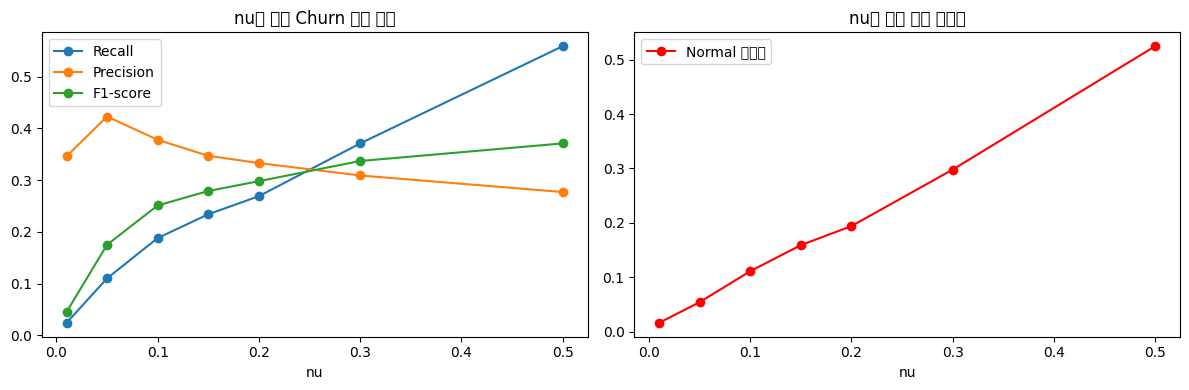

In [26]:
df_nu = pd.DataFrame(results_nu)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_nu.plot(x="nu", y=["Recall", "Precision", "F1-score"], marker="o", ax=axes[0])
axes[0].set_title("nu에 따른 Churn 탐지 성능")
axes[0].set_xlabel("nu"); axes[0].legend()

df_nu.plot(x="nu", y="Normal 오탐률", marker="o", color="red", ax=axes[1])
axes[1].set_title("nu에 따른 정상 오탐률")
axes[1].set_xlabel("nu")

plt.tight_layout()
plt.show()

In [27]:
results_nu_high = []
for nu in [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]:
    model = OneClassSVM(kernel="rbf", gamma="auto", nu=nu)
    model.fit(X_train_normal)
    pred = model.predict(X_test_scaled)

    actual_anom = (Y_test == 1).astype(int)
    pred_anom = (pred == -1).astype(int)

    results_nu_high.append({
        "nu": nu,
        "Recall": round(recall_score(actual_anom, pred_anom), 3),
        "Precision": round(precision_score(actual_anom, pred_anom), 3),
        "F1-score": round(f1_score(actual_anom, pred_anom), 3),
        "Normal 오탐률": round(((Y_test == 0) & (pred == -1)).sum() / (Y_test == 0).sum(), 3),
        "Churn 탐지": f"{pred_anom[Y_test == 1].sum()}/{(Y_test == 1).sum()}",
    })

pd.DataFrame(results_nu_high)

,nu,Recall,Precision,F1-score,Normal 오탐률,Churn 탐지
0,0.50,0.559,0.277,0.371,0.525,208/372
1,0.60,0.667,0.279,0.393,0.621,248/372
2,0.70,0.761,0.274,0.403,0.724,283/372
3,0.75,0.788,0.273,0.406,0.755,293/372
4,0.80,0.820,0.268,0.404,0.805,305/372
5,0.85,0.874,0.266,0.408,0.866,325/372
6,0.90,0.917,0.265,0.411,0.915,341/372
7,0.95,0.973,0.269,0.421,0.953,362/372


## 7) 모델 결과 분석 및 비교

**[과제]** 써니는 지금까지 클래스 불균형 해결을 위해 시도한 Resampling과 One-Class Learning 중, 이 이탈 탐지 문제에는 어떤 접근이 더 적합한지 판단하고자 합니다. AI와 함께 두 접근의 성능을 한 표에 정리하고 어떤 상황에서 어떤 방법이 유리한지 인사이트를 도출해 보세요.

In [28]:
from xgboost import XGBClassifier
from sklearn.svm import OneClassSVM

results_all = []

# ===== 1) Resampling + XGBoost =====
sampling_datasets = {
    "Before": (X_train_scaled, Y_train),
    "TomekLinks": (X_TomekLinks, Y_TomekLinks),
    "SMOTE": (X_SMOTE, Y_SMOTE),
    "SMOTE+Tomek": (X_SMOTETomek, Y_SMOTETomek),
    "ADASYN": (X_ADASYN, Y_ADASYN),
}

for name, (X_tr, Y_tr) in sampling_datasets.items():
    neg, pos = (Y_tr == 0).sum(), (Y_tr == 1).sum()
    xgb = XGBClassifier(
        n_estimators=100, max_depth=6,
        scale_pos_weight=neg / pos, random_state=42, eval_metric="logloss"
    )
    xgb.fit(X_tr, Y_tr)
    pred = xgb.predict(X_test_scaled)

    results_all.append({
        "접근": "Resampling + XGBoost",
        "방법": name,
        "Accuracy": round(accuracy_score(Y_test, pred), 3),
        "Precision": round(precision_score(Y_test, pred, pos_label=1), 3),
        "Recall": round(recall_score(Y_test, pred, pos_label=1), 3),
        "F1-score": round(f1_score(Y_test, pred, pos_label=1), 3),
    })

# ===== 2) One-Class SVM (SVDD) =====
X_train_normal = X_train_scaled[Y_train == 0]

for nu in [0.1, 0.3, 0.5, 0.9, 0.95]:
    oc = OneClassSVM(kernel="rbf", gamma="auto", nu=nu)
    oc.fit(X_train_normal)
    pred = oc.predict(X_test_scaled)

    actual_anom = (Y_test == 1).astype(int)
    pred_anom = (pred == -1).astype(int)

    results_all.append({
        "접근": "One-Class (SVDD)",
        "방법": f"nu={nu}",
        "Accuracy": round(accuracy_score(actual_anom, pred_anom), 3),
        "Precision": round(precision_score(actual_anom, pred_anom), 3),
        "Recall": round(recall_score(actual_anom, pred_anom), 3),
        "F1-score": round(f1_score(actual_anom, pred_anom), 3),
    })

# ===== 3) 한 표로 정리 =====
comparison_table = pd.DataFrame(results_all)
comparison_table = comparison_table.sort_values("F1-score", ascending=False).reset_index(drop=True)
comparison_table

,접근,방법,Accuracy,Precision,Recall,F1-score
0,Resampling + XGBoost,TomekLinks,0.774,0.558,0.702,0.621
1,Resampling + XGBoost,Before,0.778,0.568,0.677,0.618
2,Resampling + XGBoost,SMOTE+Tomek,0.777,0.570,0.645,0.605
3,Resampling + XGBoost,SMOTE,0.762,0.542,0.645,0.589
4,Resampling + XGBoost,ADASYN,0.753,0.528,0.632,0.575
5,One-Class (SVDD),nu=0.95,0.293,0.269,0.973,0.421
6,One-Class (SVDD),nu=0.9,0.305,0.265,0.917,0.411
7,One-Class (SVDD),nu=0.5,0.498,0.277,0.559,0.371
8,One-Class (SVDD),nu=0.3,0.614,0.309,0.371,0.337
9,One-Class (SVDD),nu=0.1,0.703,0.378,0.188,0.251


/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_4287/1603656213.py:6: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_4287/1603656213.py:6: UserWarning: Glyph 48277 (\N{HANGUL SYLLABLE BEOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_4287/1603656213.py:6: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_4287/1603656213.py:6: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_4287/1603656213.py:6: UserWarning: Glyph 51217 (\N{HANGUL SYLLABLE JEOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_4287

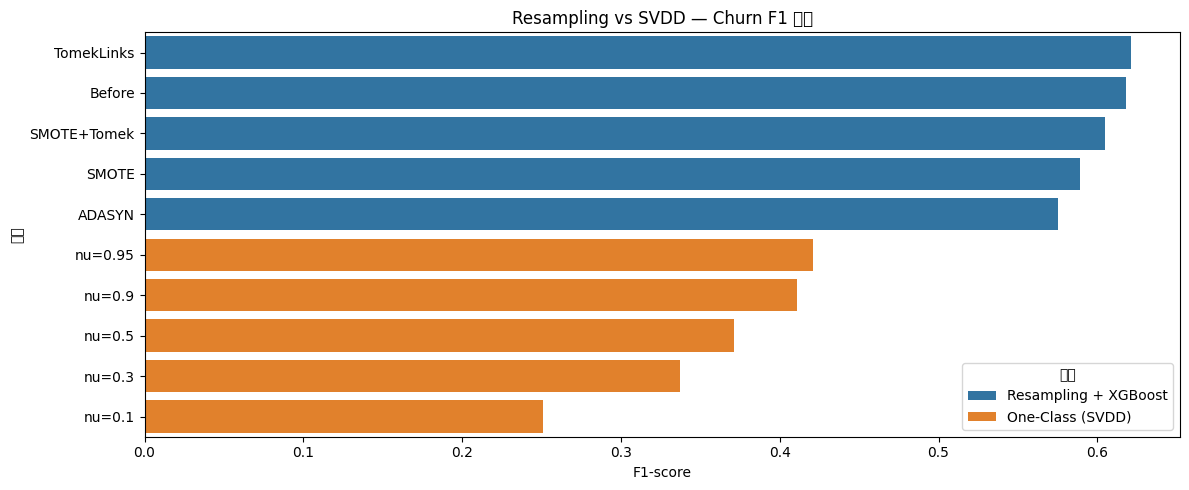

In [29]:
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.barplot(data=comparison_table, x="F1-score", y="방법", hue="접근", dodge=False)
plt.title("Resampling vs SVDD — Churn F1 비교")
plt.tight_layout()
plt.show()